# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:** $x \in \mathbb{R}^3$, $f(x) = \tfrac12x^\top x - c^\top x$ с $c = \begin{pmatrix} 1 \\ 2 \\ 3\end{pmatrix}$, $g(x) = Ax - b$ c $A = \begin{pmatrix} 1 & 1 & 1 \\ 1 & 0 & -1\end{pmatrix}$ и $b = \begin{pmatrix} 1 \\ 0\end{pmatrix}$, $h$ нет. Целевая функция квадратичная, ограничения линейные - это QP. В целевой функции  $Q = E$, задача выпукла.

In [2]:
point = np.array([1.0, 2.0, 3.0])
A_eq = np.array([[1.0, 1.0, 1.0],
                 [1.0, 0.0, -1.0]])
b_eq = np.array([1.0, 0.0])

result = minimize(
    fun=lambda x: 0.5 * np.sum((x - point) ** 2),
    x0=np.zeros(3),
    jac=lambda x: x - point,
    constraints={
        "type": "eq",
        "fun": lambda x: A_eq @ x - b_eq,
        "jac": lambda x: A_eq,
    },
    method="SLSQP",
    options={"ftol": 1e-12},
)

if not result.success:
    raise RuntimeError(result.message)

x_star = result.x
print("x* =", np.round(x_star, 12))
print("Расстояние =", np.linalg.norm(x_star - point))
print("Нарушение ограничений =", A_eq @ x_star - b_eq)


x* = [0.33333333 0.33333333 0.33333333]
Расстояние = 3.2145502536643185
Нарушение ограничений = [0.00000000e+00 5.55111512e-17]


**(б)**

**Ответ:** $x \in \mathbb{R}^n$, где $x_j$ - количество купленного продукта j, $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$, $c \in \mathbb{R}^n$ ($A$, $b$, $c$ - взяты из условий), $f(x) = c^\top x$, $h(x) = \begin{pmatrix} A \\ I_n \end{pmatrix}x - \begin{pmatrix} b \\ 0_n \end{pmatrix} = \begin{pmatrix} Ax-b \\ x \end{pmatrix}$, $g$ нет. Целевая функция линейная, ограничения линейные - это LP. Задача выпукла.

**(в)**

**Ответ:** (Прямоугольник однозначно задаётся одной точкой на окружности в первой четверти. $f_{rectangle}(x1,x2) = \begin{pmatrix} x1 & x2 \\ -x1 & x2 \\-x1 & -x2 \\x1 & -x2\end{pmatrix}$)

$x \in \mathbb{R}^2$, $f(x) = \tfrac12x^\top Q x$ с $Q = \begin{pmatrix} 0 & -4 \\ -4 & 0\end{pmatrix}$, $g(x) = x^\top x - 1$, $h(x) = x$. Целевая функция квадратична, равенство квадратично - это QCQP. Допустимое множество невыпукло, задача невыпукла.

**(г)**

**Ответ:** $x \in \mathbb{R}^3$ — параметры модели, $f(x)=\frac12\sum_{i=1}^{N}\left(x_1\sin(x_2t_i+x_3)-y_i\right)^2$, ограничений нет. В функции есть $\sin$, поэтому это NLP.

Докажем, что задача невыпукла, показав, что матрица вторых производных не является положительно полуопределённой.

$$f'_{x_3}(x)=\sum_{i=1}^N\left[\frac{x_1^2}{2}\sin\left(2(x_2t_i+x_3)\right)-x_1y_i\cos(x_2t_i+x_3)\right],$$

$$f''_{x_3x_3}(x)=\sum_{i=1}^N\left[x_1^2\cos\left(2(x_2t_i+x_3)\right)+x_1y_i\sin(x_2t_i+x_3)\right].$$

В точке $x^*=(x_1,0,\pi/2)$ имеем

$$f''_{x_3x_3}(x^*)=x_1\sum_{i=1}^N y_i-Nx_1^2=x_1\left(\sum_{i=1}^N y_i-Nx_1\right).$$

При любой сумме $S=\sum_{i=1}^N y_i$ можно выбрать такой $x_1=1+|S|/N>0$, что $f''_{x_3x_3}(x^*)<0$. Следовательно, гессиан $\nabla^2f(x^*)$ не является положительно полуопределённым, поэтому функция $f$ невыпукла.

**(д, бонус)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

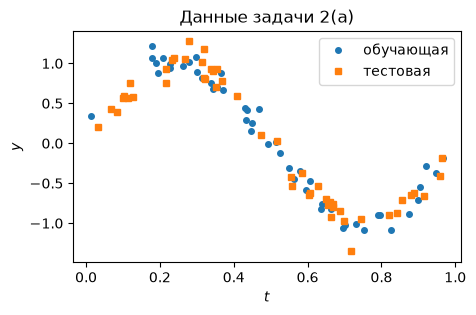

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

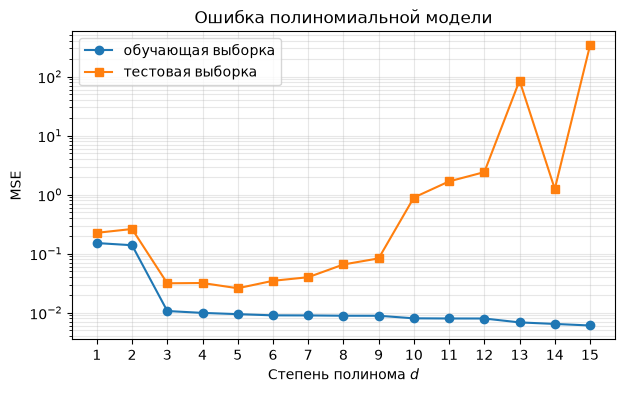

In [4]:
degrees = np.arange(1, 16)
train_mse = []
test_mse = []

for d in degrees:
    A_train = np.vander(t_train, d + 1, increasing=True)
    A_test = np.vander(t_test, d + 1, increasing=True)

    coefficients, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)

    y_train_pred = A_train @ coefficients
    y_test_pred = A_test @ coefficients
    train_mse.append(np.mean((y_train - y_train_pred) ** 2))
    test_mse.append(np.mean((y_test - y_test_pred) ** 2))

train_mse = np.array(train_mse)
test_mse = np.array(test_mse)

plt.figure(figsize=(7, 4))
plt.semilogy(degrees, train_mse, "o-", label="обучающая выборка")
plt.semilogy(degrees, test_mse, "s-", label="тестовая выборка")
plt.xticks(degrees)
plt.xlabel("Степень полинома $d$")
plt.ylabel("MSE")
plt.title("Ошибка полиномиальной модели")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


**Ответ:** Ошибка в обучающей выборке монотонна, так как каждый полином включает в себя предыдущий и следовательно не может быть хуже. Однако в выборке всего 50 элементов, что немного. Этого хватает для построения близкого к синусу полинома, условно, до 3 или 4 степени, однако с увелечением степени полинома усиливается переобучение. В итоге получаем, что полиномы выше 10 степени очень плохо обобщаются на новые данные.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
tol = 1e-9

def solve_diet(requirements):
    result = linprog(
        c,
        A_ub=-A,
        b_ub=-requirements,
        bounds=(0, None),
        method="highs",
    )
    if not result.success:
        raise RuntimeError(result.message)

    x = result.x
    constraint_slack = A @ x - requirements
    active_constraint = np.flatnonzero(
        np.isclose(constraint_slack, 0.0, atol=tol, rtol=0.0)
    ) + 1
    active_nonnegativity = np.flatnonzero(
        np.isclose(x, 0.0, atol=tol, rtol=0.0)
    ) + 1

    return result, constraint_slack, active_constraint, active_nonnegativity


def print_solution(title, result, constraint_slack, active_constraint, active_nonnegativity):
    print(title)
    print("x =", np.round(result.x, 10))
    print("Стоимость =", result.fun)
    print("Невязки Ax - b =", np.round(constraint_slack, 10))
    print("Активные ограничения Ax >= b:", active_constraint.tolist())
    print("Активные ограничения x >= 0:", active_nonnegativity.tolist())


initial = solve_diet(b)
print_solution("Исходная задача", *initial)

b_changed = b.copy()
b_changed[0] += 1.0
changed = solve_diet(b_changed)
print()
print_solution("После увеличения b_1 на единицу", *changed)

print()
print("Изменение x =", np.round(changed[0].x - initial[0].x, 10))
print("Изменение стоимости =", changed[0].fun - initial[0].fun)


Исходная задача
x = [ 2.  4. -0.  0.]
Стоимость = 16.0
Невязки Ax - b = [0. 0. 0.]
Активные ограничения Ax >= b: [1, 2, 3]
Активные ограничения x >= 0: [3, 4]

После увеличения b_1 на единицу
x = [1.88888889 3.55555556 0.         0.66666667]
Стоимость = 17.11111111111111
Невязки Ax - b = [0. 0. 0.]
Активные ограничения Ax >= b: [1, 2, 3]
Активные ограничения x >= 0: [3]

Изменение x = [-0.11111111 -0.44444444  0.          0.66666667]
Изменение стоимости = 1.1111111111111107


**Ответ:** Да, решение изменилось и стоимость увеличилась, что логично, так как увеличились требования к количеству веществ. Активные ограничения в $Ax \ge b$ не поменялись, относительно неравенства $x \ge 0$ $x_4$ перестал быть равен 0 и больше не активное ограничение.